# Basic Features And Overview Of Possibilities


In [2]:
# -*- coding: utf-8 -*-
"""
 * Copyright (c) 2023 Alexandre Gauvain, Ronan Abhervé, Jean-Raynald de Dreuzy
 *
 * This program and the accompanying materials are made available under the
 * terms of the Eclipse Public License 2.0 which is available at
 * http://www.eclipse.org/legal/epl-2.0, or the Apache License, Version 2.0
 * which is available at https://www.apache.org/licenses/LICENSE-2.0.
 *
 * SPDX-License-Identifier: EPL-2.0 OR Apache-2.0
"""



'\n * Copyright (c) 2023 Alexandre Gauvain, Ronan Abhervé, Jean-Raynald de Dreuzy\n *\n * This program and the accompanying materials are made available under the\n * terms of the Eclipse Public License 2.0 which is available at\n * http://www.eclipse.org/legal/epl-2.0, or the Apache License, Version 2.0\n * which is available at https://www.apache.org/licenses/LICENSE-2.0.\n *\n * SPDX-License-Identifier: EPL-2.0 OR Apache-2.0\n'

In [3]:
# Libraries installed by default
import sys
import os
import pandas as pd
import numpy as np
import matplotlib as mpl        # install automatically by geopandas
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import imageio
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False

# ROOT DIRECTORY
from os.path import dirname, abspath
try:
    root_dir = '/home/bb/Documents/01_Git_Repository/01-HydroModPy-dev'
except NameError:
    root_dir = os.getcwd()
sys.path.append(root_dir)

# HYDROMODPY MODULES
from hydromodpy import watershed_root
from hydromodpy.display import export_vtuvtk, visualization_watershed, visualization_results
from hydromodpy.tools import toolbox
fontprop = toolbox.plot_params(8,15,18,20)  # small, medium, interm, large



In [4]:

example_path = os.path.join(root_dir, "examples", "02_basic_features_and_overview_of_possibilities/")
data_path = os.path.join(example_path, "data/")

# The folder out_path is created in the example_path root directory:
out_path = os.path.join(root_dir,'examples', 'results')
# Or define it manually
# out_path = 'D:/_HydroModPy/_results'

print('The results of the example will be saved here :', out_path)



The results of the example will be saved here : /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results


In [ ]:

### Choice of model domain initialization (shapefile, .csv library of coordinates, )
# case = 'FromSHP'    # from a shapefile: clip a provided DEM
# case = 'FromLIB'  # from a library of coordinates: extract the catchment from a DEM
# case = 'FromXYV'  # from a XY coordinates: the catchment is extracted from outlet coordinates
case = 'FromDEM'  # from a DEM: the model domain is directly the DEM provided
###

if case == 'FromLIB':
    dem_path = os.path.join(data_path, 'regional dem.tif')
    watershed_name = 'Example_02_Library'
    from_lib = os.path.join(data_path,'watershed_library.csv')
    from_dem = None # [path, cell size]
    from_shp = None # [path, buffer size]
    from_xyv = None # [x, y, snap distance, buffer size]
    bottom_path = None # path
    save_object = True

if case == 'FromDEM':
    dem_path = os.path.join(data_path, 'conceptual dem.tif')
    watershed_name = 'Example_02_Topography'
    from_lib = None # os.path.join(root_dir,'watershed_library.csv')
    from_dem = [dem_path, 100] # [path, cell size]
    from_shp = None # [path, buffer size]
    from_xyv = None # [x, y, snap distance, buffer size]
    bottom_path = None # path
    save_object = True

if case == 'FromSHP':
    dem_path = os.path.join(data_path, 'regional dem.tif')
    watershed_name = 'Example_02_Shapefile'
    from_lib = None # os.path.join(root_dir,'watershed_library.csv')
    from_dem = None # [path, cell size]
    from_shp = [data_path + '/' + 'conceptual shp.shp', 10] # [path, buffer size]
    from_xyv = None # [x, y, snap distance, buffer size]
    bottom_path = None # path
    save_object = True

if case == 'FromXYV':
    dem_path = os.path.join(data_path, 'regional dem.tif')
    watershed_name = 'Example_02_Coordinates'
    from_lib = None # os.path.join(root_dir,'watershed_library.csv')
    from_dem = None # [path, cell size]
    from_shp = None # [path, buffer size]
    from_xyv = [127307.551 , 6835727.567 , 200 , 10 , 'EPSG:2154'] # [x, y, snap distance, buffer size, crs proj]
    bottom_path = None # path
    save_object = True



In [6]:

print('##### '+watershed_name.upper()+' #####')

load = True
BV = watershed_root.Watershed(dem_path=dem_path,
                              out_path=out_path,
                              load=load,
                              watershed_name=watershed_name,
                              from_lib=from_lib, # os.path.join(root_dir,'watershed_library.csv')
                              from_dem=from_dem, # [path, cell size]
                              from_shp=from_shp, # [path, buffer size]
                              from_xyv=from_xyv, # [x, y, snap distance, buffer size]
                              bottom_path=bottom_path, # path
                              save_object=save_object)

# Paths generated automatically but necessary for plots
stable_folder = os.path.join(out_path,watershed_name,"results_stable")
simulations_folder = os.path.join(out_path,watershed_name,"results_simulations")



[INFO]       __  __          __           __  ____          ________     


[INFO]      / / / /         / /          /  \/   /         / / __  /     


[INFO]     / /_/ /_  ______/ /________  /       /___  ____/ / /_/ /_  __ 


[INFO]    / __  / / / / __  / ___/ __ \/ /\,-/ / __ \/ __  / ____/ / / / 


[INFO]   / / / / /_/ / /_/ / /  / /_/ / /   / / /_/ / /_/ / /   / /_/ /  


[INFO]  /_/ /_/\__, /_____/_/   \____/_/   /_/\____/_____/_/____\__, /   


[INFO]        /____/ Hydrological Modelling in Python /_____________/    


[INFO]                                                                   


[INFO] Python object was successfully loaded as requested; imported from output directory /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_02_Topography


##### EXAMPLE_02_TOPOGRAPHY #####


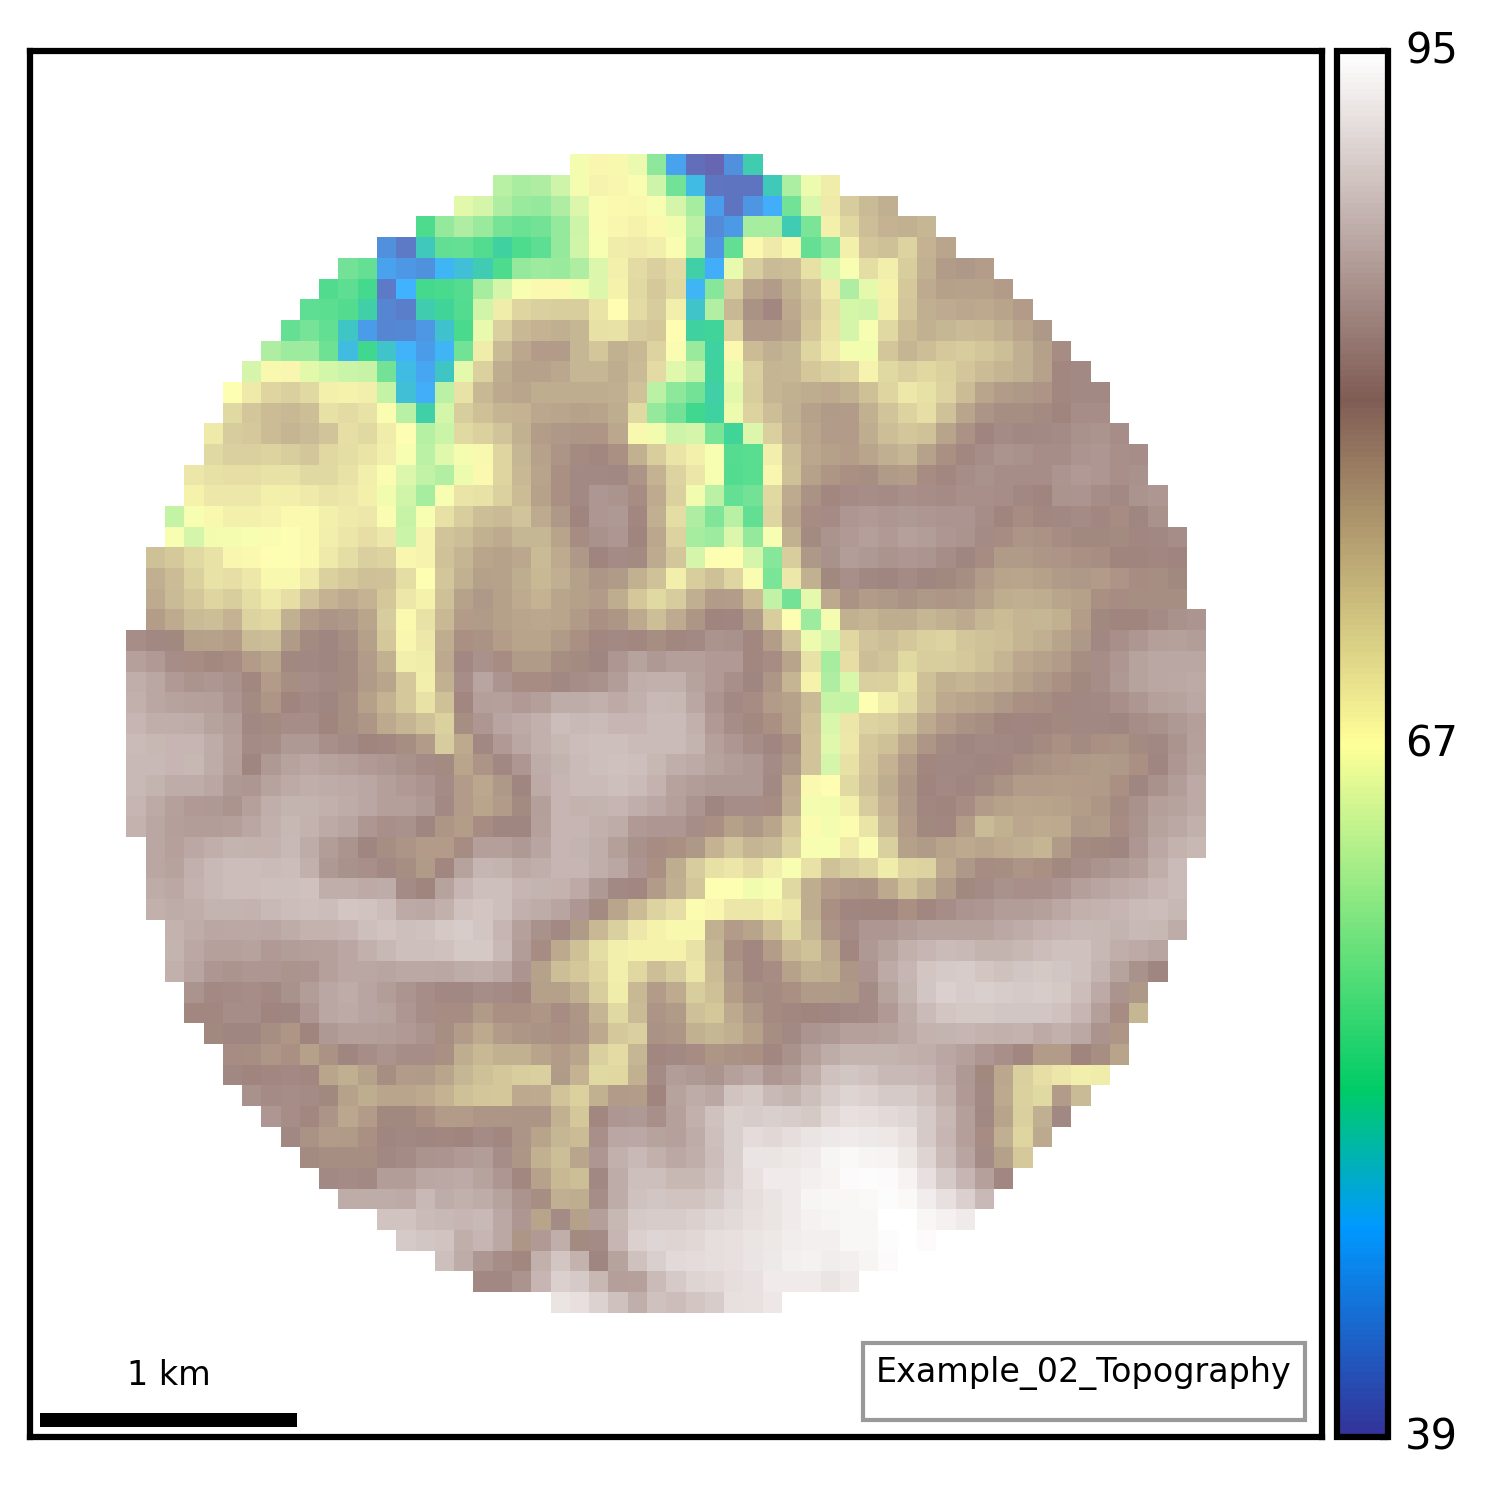

In [7]:

if from_dem == None:
    # Clip specific data at the catchment scale
    BV.add_geology(data_path, types_obs='GEO1M.shp', fields_obs='CODE_LEG')
    BV.add_hydrography(data_path, types_obs=['regional stream network'], fields_obs=['fid'])
    BV.add_hydrometry(data_path, 'france hydrometric stations.shp')

# General plot of the study site
if from_dem == None:
    visualization_watershed.watershed_local(dem_path, BV)
    visualization_watershed.watershed_geology(BV)
visualization_watershed.watershed_dem(BV)



[INFO] Initializing climatic module parameters


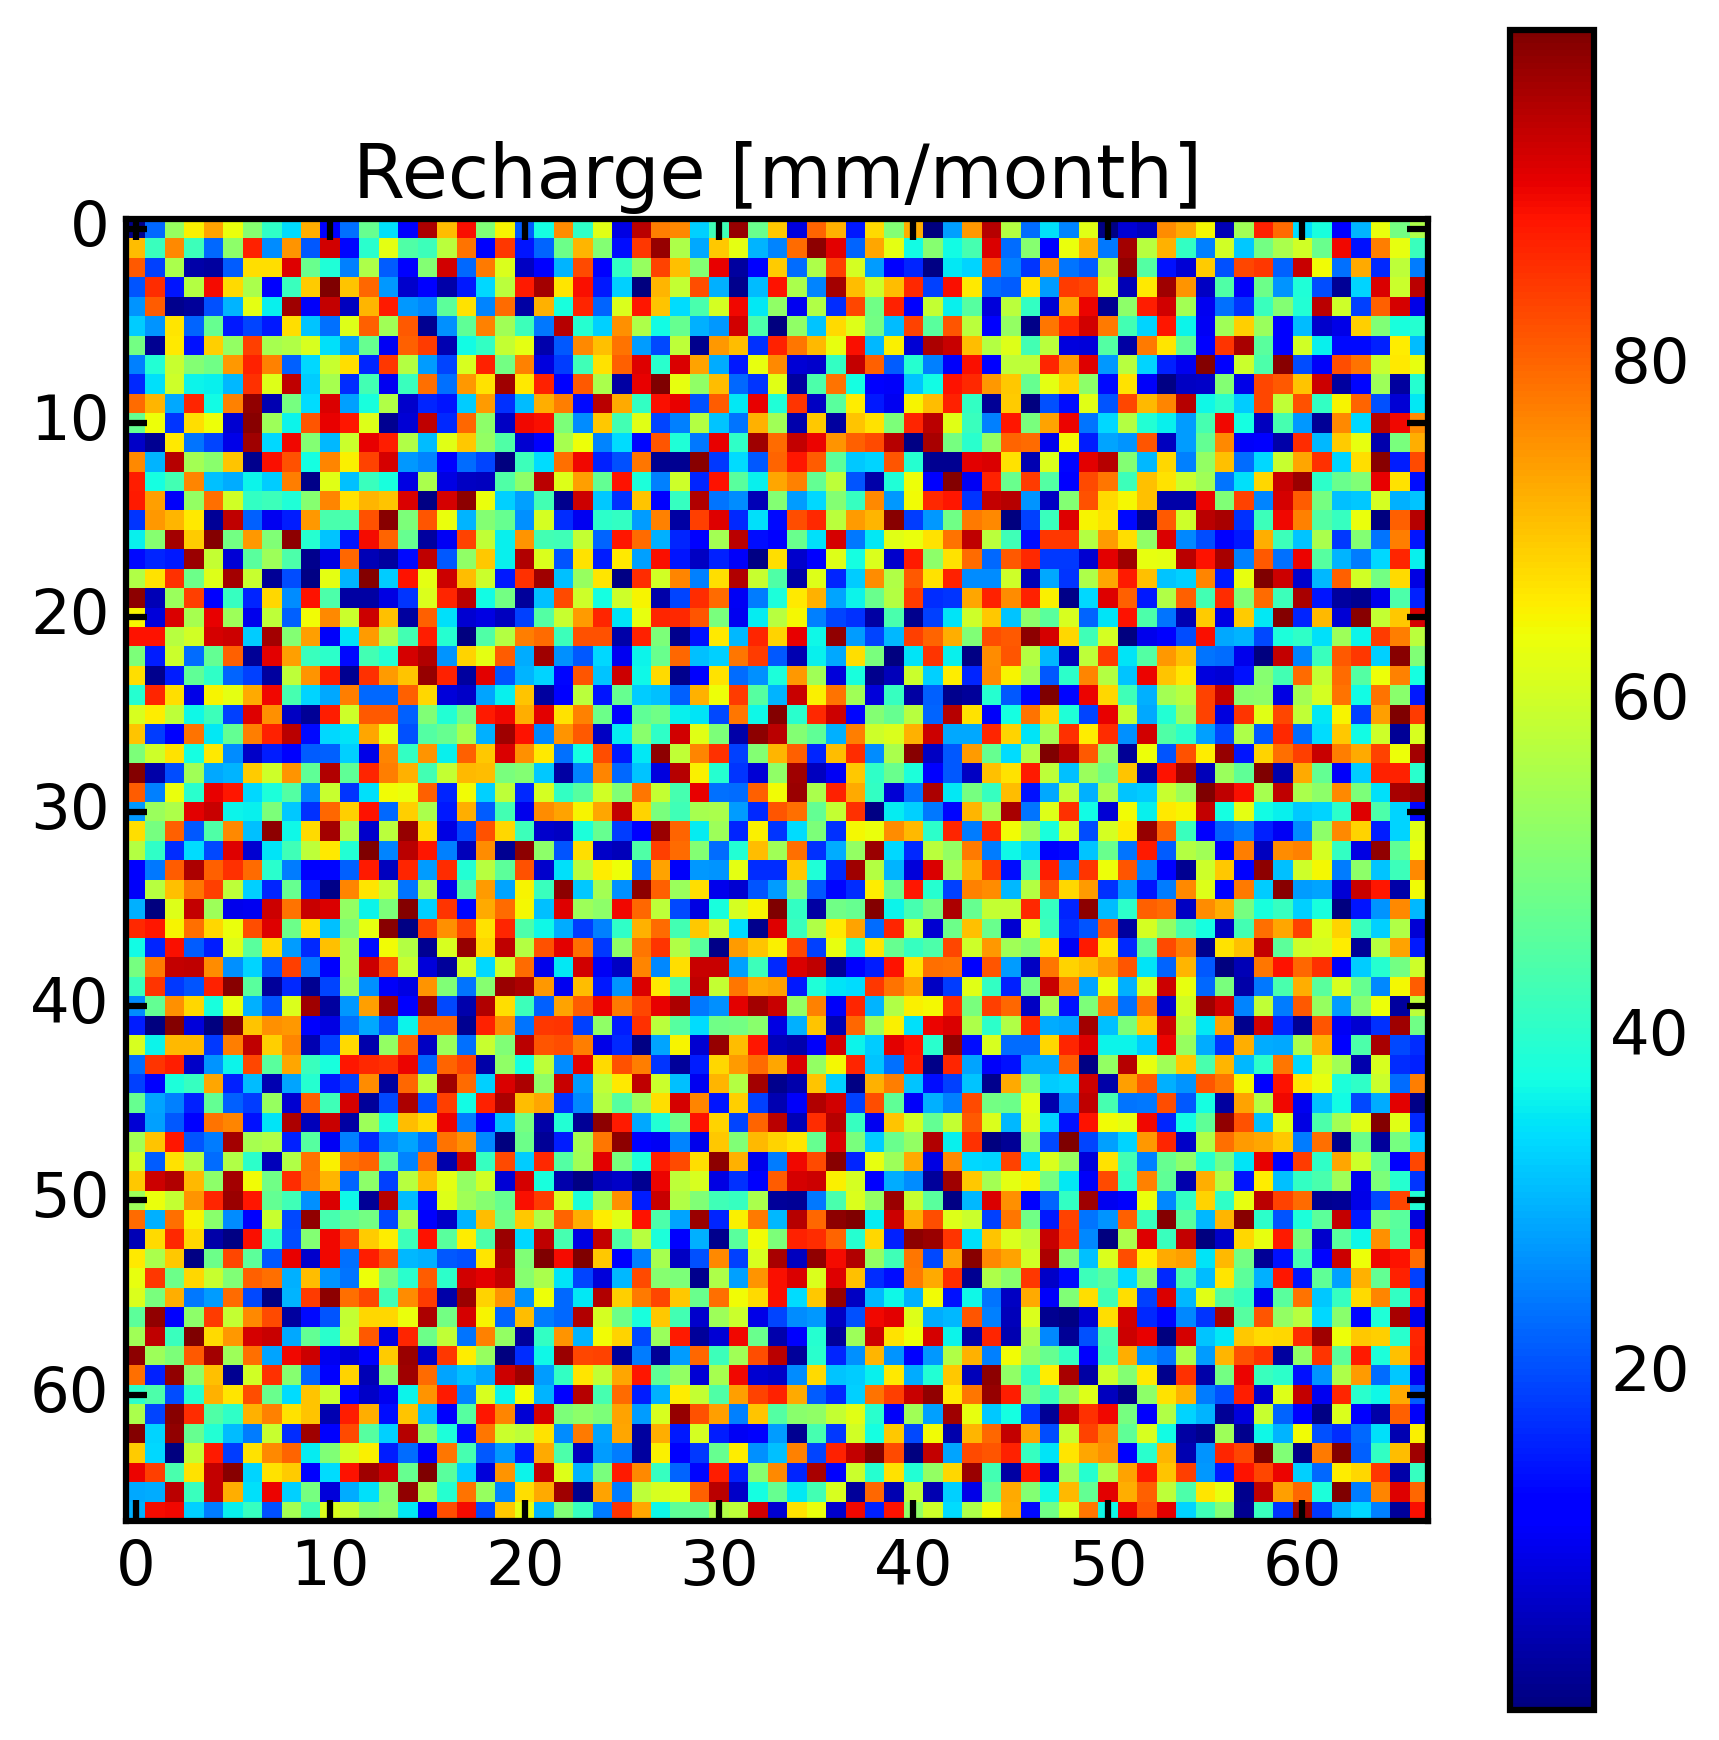

In [ ]:

# # Necessary to set model parameters
BV.add_climatic()

### Choice the case of recharge input
# recharge_data = 'manual'
# recharge_data = 'reanalysis'
# recharge_data = 'explore1'
# recharge_data = 'explore2'
# recharge_data = 'synthetic'
# recharge_data = 'raster'
# recharge_data = 'evapotranspiration'
recharge_data = 'dictionary'
###

if recharge_data == 'manual':

    time_series = pd.Series([10,20,30,40,50,60,60,50,40,30,20,10]) # mm/month
    BV.climatic.update_recharge(time_series, sim_state='transient')
    fig, ax = plt.subplots(1,1, figsize=(6,3))
    R = BV.climatic.recharge / 1000 / 30
    r = R * 0.1
    ax.plot(R, label='recharge_manual', c='dodgerblue', lw=2)
    ax.plot(r, label='runoff_manual', c='navy', lw=2)
    ax.set_xlabel('Months')
    ax.set_ylabel('[mm/month]')
    ax.legend()

if recharge_data == 'reanalysis':
    BV.climatic.update_recharge_reanalysis(path_file=os.path.join(data_path,'_climate_REANALYSIS.csv'),
                                           clim_mod='REA',
                                           clim_sce='historic',
                                           first_year=1990,
                                           last_year=2019,
                                           time_step='D',
                                           sim_state='transient')
    BV.climatic.update_runoff_reanalysis(path_file=os.path.join(data_path,'_climate_REANALYSIS.csv'),
                                         clim_mod='REA',
                                         clim_sce='historic',
                                         first_year=1990,
                                         last_year=2019,
                                         time_step='D',
                                         sim_state='transient')
    fig, ax = plt.subplots(1,1, figsize=(6,3))
    R = BV.climatic.recharge.resample('Y').sum()*1000
    r = BV.climatic.runoff.resample('Y').sum()*1000
    ax.plot(R, label='echarge_reanalysis', c='dodgerblue', lw=2)
    ax.plot(r, label='runoff_reanalysis', c='navy', lw=2)
    ax.set_xlabel('Date')
    ax.set_ylabel('[mm/year]')
    ax.legend()

if recharge_data == 'explore1':
    BV.climatic.update_recharge_explore1(path_file=os.path.join(data_path,'_climate_EXPLORE1.csv'),
                                         clim_mod='IPS1',
                                         clim_sce='RCP8.5',
                                         first_year=2020,
                                         last_year=2099,
                                         time_step='D',
                                         sim_state='transient')
    BV.climatic.update_runoff_explore1(path_file=os.path.join(data_path,'_climate_EXPLORE1.csv'),
                                         clim_mod='IPS1',
                                         clim_sce='RCP8.5',
                                         first_year=2020,
                                         last_year=2099,
                                         time_step='D',
                                         sim_state='transient')
    fig, ax = plt.subplots(1,1, figsize=(6,3))
    R = BV.climatic.recharge.resample('Y').sum()*1000
    r = BV.climatic.runoff.resample('Y').sum()*1000
    ax.plot(R, label='recharge_explore1', c='dodgerblue', lw=2)
    ax.plot(r, label='runoff_explore1', c='navy', lw=2)
    ax.set_xlabel('Date')
    ax.set_ylabel('[mm/year]')
    ax.legend()

if recharge_data == 'explore2':
    BV.climatic.update_recharge_explore2(path_file=os.path.join(data_path,'_climate_EXPLORE2.csv'),
                                         gcm_mod='CNR',
                                         rcm_mod='ALA',
                                         sce_mod='RCP8.5',
                                         first_year=2020,
                                         last_year=2099,
                                         sim_state='transient')
    BV.climatic.update_runoff_explore2(path_file=os.path.join(data_path,'_climate_EXPLORE2.csv'),
                                         gcm_mod='CNR',
                                         rcm_mod='ALA',
                                         sce_mod='RCP8.5',
                                         first_year=2020,
                                         last_year=2099,
                                         sim_state='transient')
    fig, ax = plt.subplots(1,1, figsize=(6,3))
    R = BV.climatic.recharge.resample('Y').sum()*1000
    r = BV.climatic.runoff.resample('Y').sum()*1000
    ax.plot(R, label='recharge_explore2', c='dodgerblue', lw=2)
    ax.plot(r, label='runoff_explore2', c='navy', lw=2)
    ax.set_xlabel('Date')
    ax.set_ylabel('[mm/year]')
    ax.legend()

if recharge_data == 'synthetic':
    rtot = 500 / 1000
    shape = 24
    years = 5
    start_date = "2000-01"
    freq = 'D' # None
    dis = 'normal' # 'inverse-gaussian', 'uniform', 'normal'
    # dis = 'inverse-gaussian'
    # dis = 'uniform'

    fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=300)

    BV.climatic.update_recharge_synthetic(rtot, shape, years, start_date=start_date, freq=freq, dis=dis)
    R = BV.climatic.recharge
    r = R * 0.1
    ax.plot(R * 1000, label='recharge_synthetic', c='dodgerblue', lw=2)
    ax.plot(r * 1000, label='runoff_synthetic', c='navy', lw=2)
    ax.set_xlabel('Date')
    ax.set_ylabel('[mm/day]')
    ax.legend()
    print(R.resample('Y').sum()*1000)

if recharge_data == 'raster':

    dem_struct = imageio.imread(os.path.join(stable_folder,r'geographic/watershed_box_buff_dem.tif')) * 0
    dem_struct = dem_struct + 10/1000/30
    dem_struct[:,int(dem_struct.shape[1]/2):] = dem_struct[:,int(dem_struct.shape[1]/2):] + 1000/1000/30

    list_of_arrays = [dem_struct, dem_struct, dem_struct] # transient
    # list_of_arrays = [dem_struct] # steay

    dictio = {}

    for i in range(len(list_of_arrays)):
        dictio[i] = list_of_arrays[i]

    R = dictio.copy()
    r = R.copy()
    for i in range(len(R)):
        r[i] = r[i] * 0.1

    fig, ax = plt.subplots(1,1, figsize=(6,3))
    ax.imshow(R[0])

if recharge_data == 'evapotranspiration':

    time_series = pd.Series([10,20,30,-20,-100,-40,20,50,40,30,20,10]) # mm/month
    BV.climatic.update_recharge(time_series, sim_state='transient')
    fig, ax = plt.subplots(1,1, figsize=(6,3))
    R = BV.climatic.recharge / 1000 / 30
    r = R
    ax.plot(R, label='effective precipitation_manual', c='dodgerblue', lw=2)
    ax.set_xlabel('Months')
    ax.set_ylabel('[mm/month]')
    ax.legend()

if recharge_data == 'dictionary':

    shape_rec = np.random.rand(BV.geographic.dem_clip.shape[0],BV.geographic.dem_clip.shape[1])*100 # mm/month
    dict_rec = {}
    dict_rec[0] = shape_rec
    fig, ax = plt.subplots(1,1, figsize=(7,7))
    im = ax.imshow(dict_rec[0])
    ax.set_title('Recharge [mm/month]')
    fig.colorbar(im)
    R = dict_rec[0] / 1000 / 30
    r = R



In [9]:

# Frame settings
model_name = 'default'
box = True # or False
sink_fill = False # or True
# sim_state = 'transient' # 'steady' or 'transient'
sim_state = 'steady' # 'steady' or 'transient'
plot_cross = True
cross_ylim = [-100,100]
check_grid = True
dis_perlen = True

# Climatic settings
recharge = R.copy()
first_clim = 'mean' # or 'first or value

# Hydraulic settings
nlay = 5
lay_decay = 1. # 1 for no decay
bottom = -1 # elevation in meters, None for constant auifer thickness, or 2D matrix
if case == 'FromDEM':
    bottom = BV.geographic.dem_clip*-1
thick = 50 # if bottom is None, aquifer thickness
hk = 1e-5 * 24 * 3600 # m/day
cond_decay = 0 # exponential decay : 1/20 (half decrease at 20m)
verti_hk = None # or [ [1e-5, [0, 20]], [1e-6, [20,80]] ]
if case == 'FromDEM':
    nlay = 10
    lay_decay = 1.2
    hk = 1e-8 * 24 * 3600 # m/day
    verti_hk = [ [1e-5*24*3600, [0, 30]], [1e-7*24*3600, [30,100]] ]
cond_drain = None # or value of conductance
sy = 10 / 100 # -

# Boundary settings
bc_left = None # or value
bc_right = None # or value
sea_level = 'None' # or value based on specific data : BV.oceanic.MSL

# Particle tracking settings
zone_partic = 'domain' # or watershed



In [10]:

# Import modules
BV.add_settings()
BV.add_climatic()
BV.add_hydraulic()

# Frame settings
BV.settings.update_model_name(model_name)
BV.settings.update_box_model(box)
BV.settings.update_sink_fill(sink_fill)
BV.settings.update_simulation_state(sim_state)
BV.settings.update_check_model(plot_cross=plot_cross, cross_ylim=cross_ylim, check_grid=check_grid)

# Climatic settings
BV.climatic.update_recharge(recharge, sim_state=sim_state)
BV.climatic.update_first_clim(first_clim)

# Hydraulic settings
BV.hydraulic.update_nlay(nlay) # 1
BV.hydraulic.update_lay_decay(lay_decay) # 1
BV.hydraulic.update_bottom(bottom) # None
BV.hydraulic.update_thick(thick) # 30 / intervient pas si bottom != None
BV.hydraulic.update_hk(hk)
BV.hydraulic.update_sy(sy)
BV.hydraulic.update_hk_vertical(verti_hk)
BV.hydraulic.update_cond_drain(cond_drain)

# Boundary settings
BV.settings.update_bc_sides(bc_left, bc_right)
BV.add_oceanic(sea_level)
BV.settings.update_dis_perlen(dis_perlen=dis_perlen)

# Particle tracking settings
BV.settings.update_input_particles(zone_partic=BV.geographic.watershed_box_buff_dem) # or 'seepage_path'



[INFO] Initializing settings module for groundwater parameters


[INFO] Initializing climatic module parameters


[INFO] Initializing hydraulic module for parameter setup


[WARNING] MODFLOW grid connectivity check found 25 problematic cells


FloPy is using the following executable to run the model: ../../../../../bin/linux/mfnwt

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: default.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:42:04

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.


[INFO] Post-processing stress period 1/1


 Run end date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:42:05
 Elapsed run time:  0.323 Seconds

  Normal termination of simulation


[INFO] Exporting watertable elevation time series


...

[INFO] Exporting seepage areas time series


[INFO] Exporting outflow drain time series


[INFO] Exporting groundwater flux time series


[INFO] Exporting groundwater storage time series


[INFO] Exporting accumulation flux time series


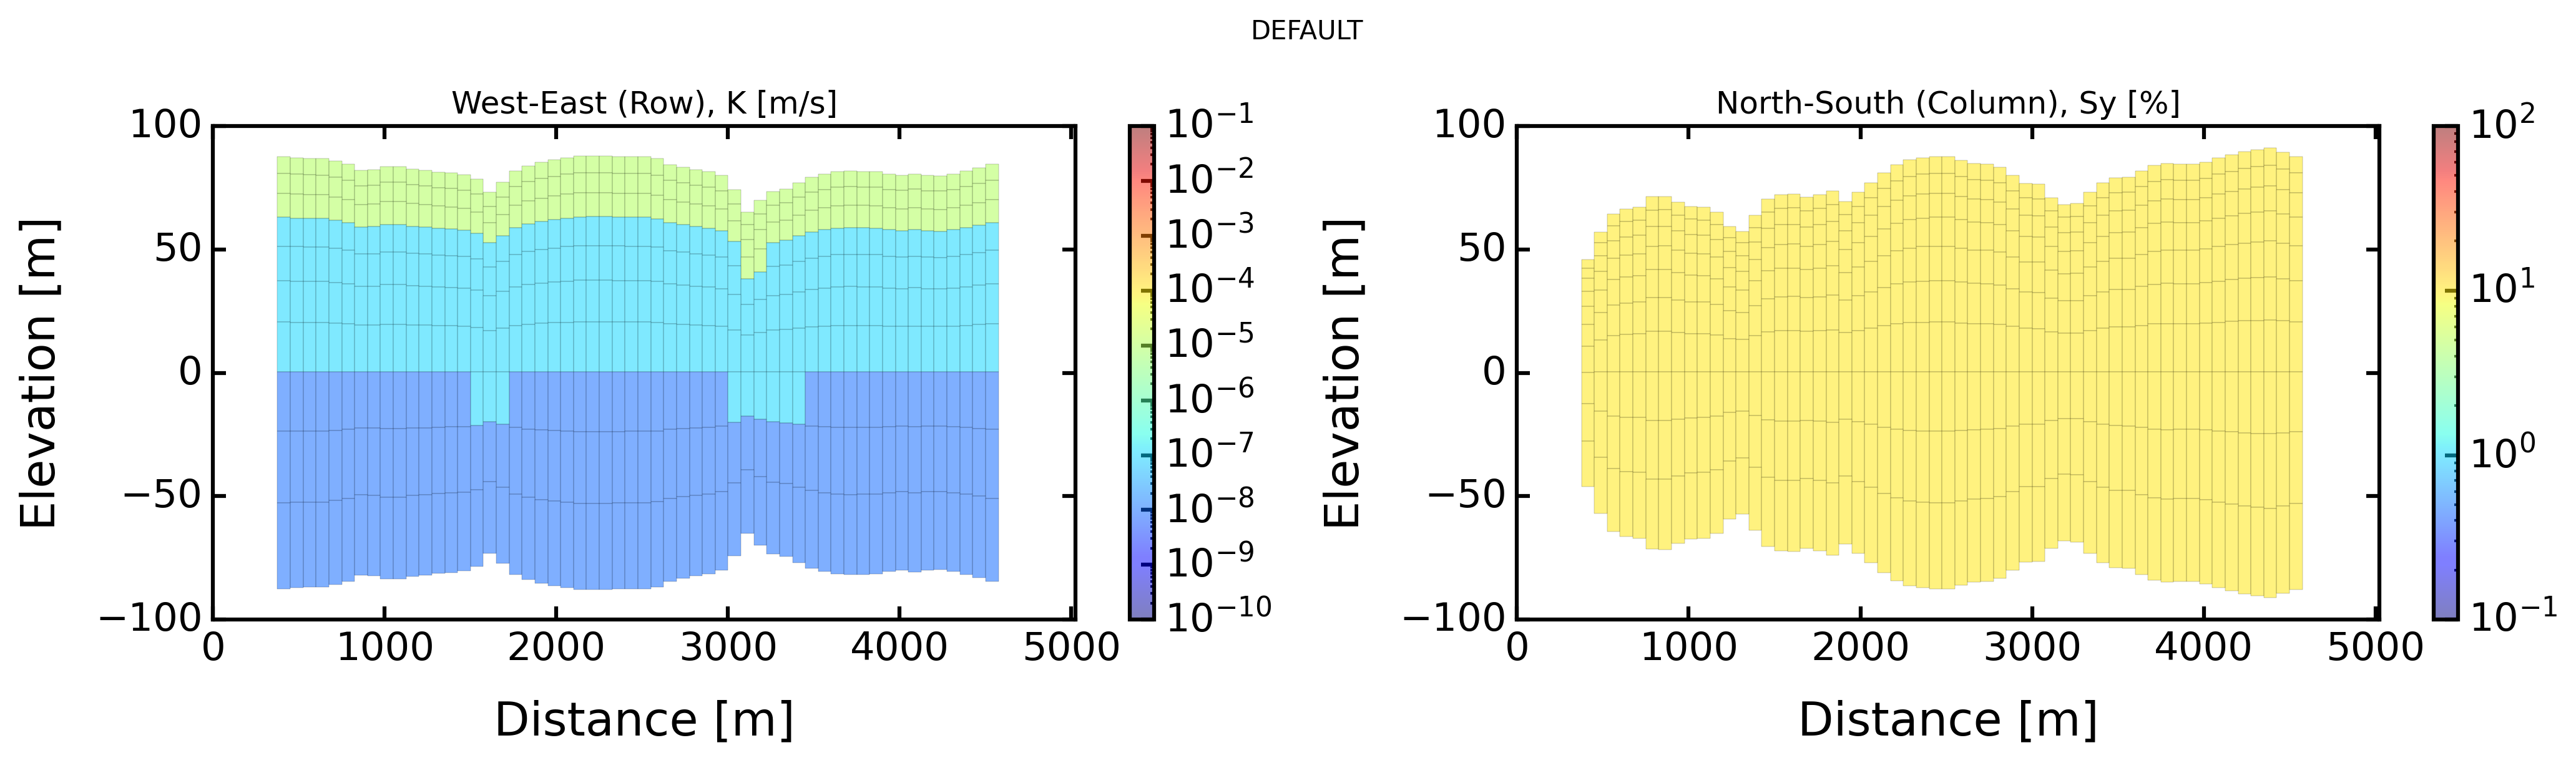

In [ ]:

model_modflow = BV.preprocessing_modflow(for_calib=False)
success_modflow = BV.processing_modflow(model_modflow, write_model=True, run_model=True)
if success_modflow == True:
    BV.postprocessing_modflow(model_modflow,
                              watertable_elevation = True,
                              watertable_depth= True,
                              seepage_areas = True,
                              outflow_drain = True,
                              groundwater_flux = True,
                              groundwater_storage = True,
                              accumulation_flux = True,
                              persistency_index=False,
                              intermittency_monthly=False,
                              intermittency_daily=False,
                              export_all_tif = False)



In [12]:

if sim_state == 'steady':
    if success_modflow == True:
        model_modpath = BV.preprocessing_modpath(model_modflow)
        success_modpath = BV.processing_modpath(model_modpath, write_model=True, run_model=True)
    if success_modpath == True:
        BV.postprocessing_modpath(model_modpath,
                                  ending_point=True,
                                  starting_point=True,
                                  pathlines_shp=True,
                                  particles_shp=True,
                                  random_id=100)



writing loc particle data
FloPy is using the following executable to run the model: ../../../../../bin/linux/mp6
Processing basic data ...
Checking head file ...
Checking budget file and building index ...
 
Run particle tracking simulation ...
Processing Time Step     1 Period     1.  Time =  1.00000E+00                                                                       
Particle tracking complete. Writing endpoint file ...                                                                               
End of MODPATH simulation. Normal termination.


(numpy.record, [('particleid', '<i4'), ('particlegroup', '<i4'), ('timepointindex', '<i4'), ('cumulativetimestep', '<i4'), ('time', '<f4'), ('x', '<f4'), ('y', '<f4'), ('z', '<f4'), ('k', '<i4'), ('i', '<i4'), ('j', '<i4'), ('grid', '<i4'), ('xloc', '<f4'), ('yloc', '<f4'), ('zloc', '<f4'), ('linesegmentindex', '<i4')])
(numpy.record, [('particleid', '<i4'), ('particlegroup', '<i4'), ('timepointindex', '<i4'), ('cumulativetimestep', '<i4'), ('time', '<f4'), ('x', '<f4'), ('y', '<f4'), ('z', '<f4'), ('k', '<i4'), ('i', '<i4'), ('j', '<i4'), ('grid', '<i4'), ('xloc', '<f4'), ('yloc', '<f4'), ('zloc', '<f4'), ('linesegmentindex', '<i4')])


In [13]:

if from_dem == None:
    subbasin_results = True
else:
    subbasin_results = False

if sim_state == 'steady':
    model_modpath = model_modpath
else:
    model_modpath = None

timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                  model_modpath=model_modpath,
                                                  subbasin_results=subbasin_results,
                                                  datetime_format=False) # or None

netcdf_results = BV.postprocessing_netcdf(model_modflow,
                                          datetime_format=False)



[INFO] Exported catchment time series to /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_02_Topography/results_simulations/default/_postprocess/_timeseries


[INFO] Exporting MODFLOW results as NetCDF for model default


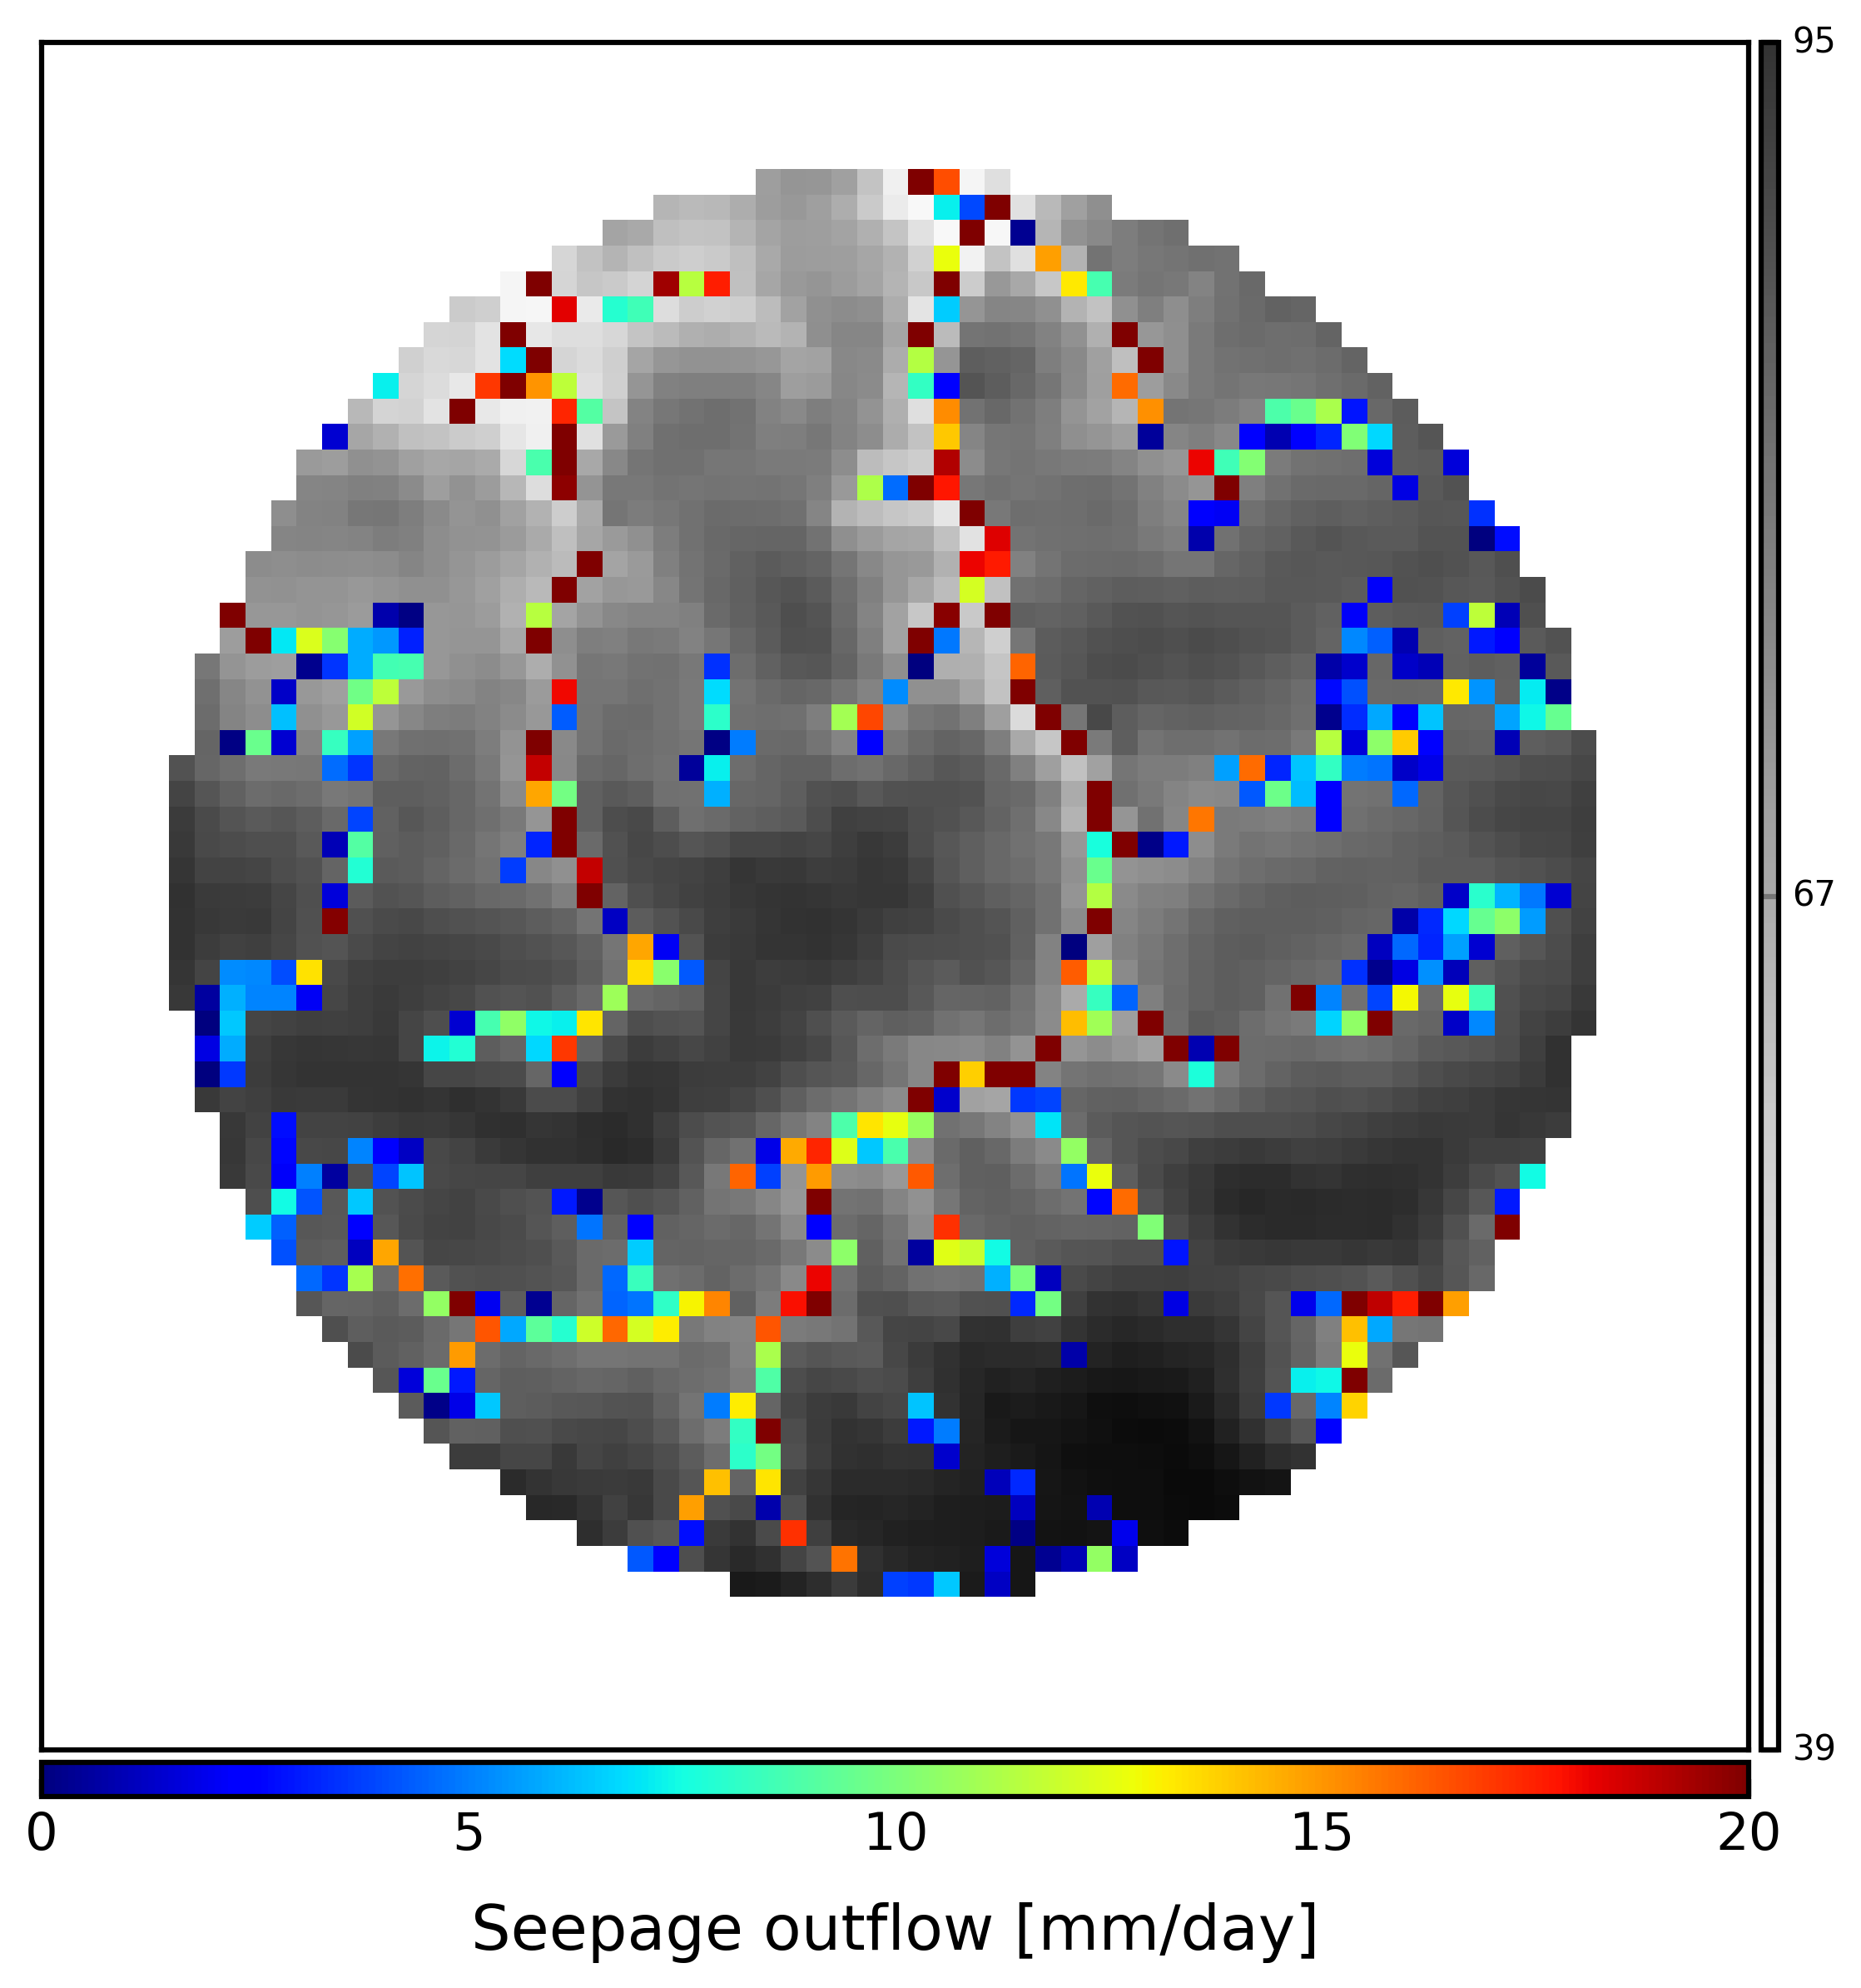

In [14]:

lead_numb = '0'
outflow = imageio.imread(os.path.join(simulations_folder,model_name,r'_postprocess/_rasters/outflow_drain_t(0).tif'))
accflow = imageio.imread(os.path.join(simulations_folder,model_name,r'_postprocess/_rasters/accumulation_flux_t(0).tif'))
demData = imageio.imread(BV.geographic.watershed_dem)
demData = np.ma.masked_array(demData, mask=demData<0)
res = BV.geographic.resolution

msk_outflow = (outflow<0)
outflow = np.ma.masked_array(outflow, mask=msk_outflow)
outflow = ( np.ma.masked_where(outflow==0, outflow) )
outflow = outflow  / (res**2)
outflow = outflow * 1000 # * 365 # mm/day or mm/year
# outflow = np.log10(outflow)

from matplotlib.colors import LightSource
ls = LightSource(azdeg=45, altdeg=45)
cmap = plt.cm.Greys
rgb = ls.shade(demData, cmap=cmap, blend_mode='soft', vert_exag=2, dx=res, dy=res)

fig, ax = plt.subplots(1, 1, figsize=(8,8), dpi=300)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
im = ax.imshow(demData, alpha=0.8, cmap=cmap)
im = ax.imshow(rgb, alpha=0.8, cmap=cmap)
cf=ax.imshow(outflow, cmap='jet', alpha=1,
             # vmin=outflow.min(), vmax=1000
             )
try:
    cont = imageio.imread(BV.geographic.watershed_contour_tif)
    ax.imshow(np.ma.masked_where(cont<0, cont), cmap=mpl.colors.ListedColormap(['k']))
except:
    pass

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.05)
fig.add_axes(cax)
cbar = fig.colorbar(im, cax=cax, orientation="vertical")

val = np.ma.masked_where(demData < 0, demData)
minVal =  int(round(np.nanmin(val[np.nonzero(val)],0)))
maxVal =  int(round(np.nanmax(val[np.nonzero(val)],0)))
meanVal = int(round(minVal+((maxVal-minVal)/2),0))
cbar.set_ticks([minVal, meanVal, maxVal])
cbar.set_ticklabels([minVal, meanVal, maxVal])
cbar.mappable.set_clim(minVal, maxVal)
cbar.ax.tick_params(labelsize=10)

cax = divider.new_vertical(size="2%", pad=0.05, pack_start=True)
fig.add_axes(cax)
cbar = fig.colorbar(cf, cax=cax, orientation="horizontal")
ticks = np.linspace(0, 20, 5)
cbar.set_ticks(ticks)
# cbar.set_ticklabels(ticks.round(1))
cbar.mappable.set_clim(0, 20)
cbar.set_label('Seepage outflow [mm/day]')

plt.tight_layout()
name_fig = 'map_discharge_' + str(lead_numb) + '.png'
plt.tight_layout()

# fig.savefig(os.path.join(simulations_folder, model_name,
#                             '_postprocess', '_figures', 'RAW_'+model_name+'.png'))



[INFO] Plotting 2D map visualizations for model default


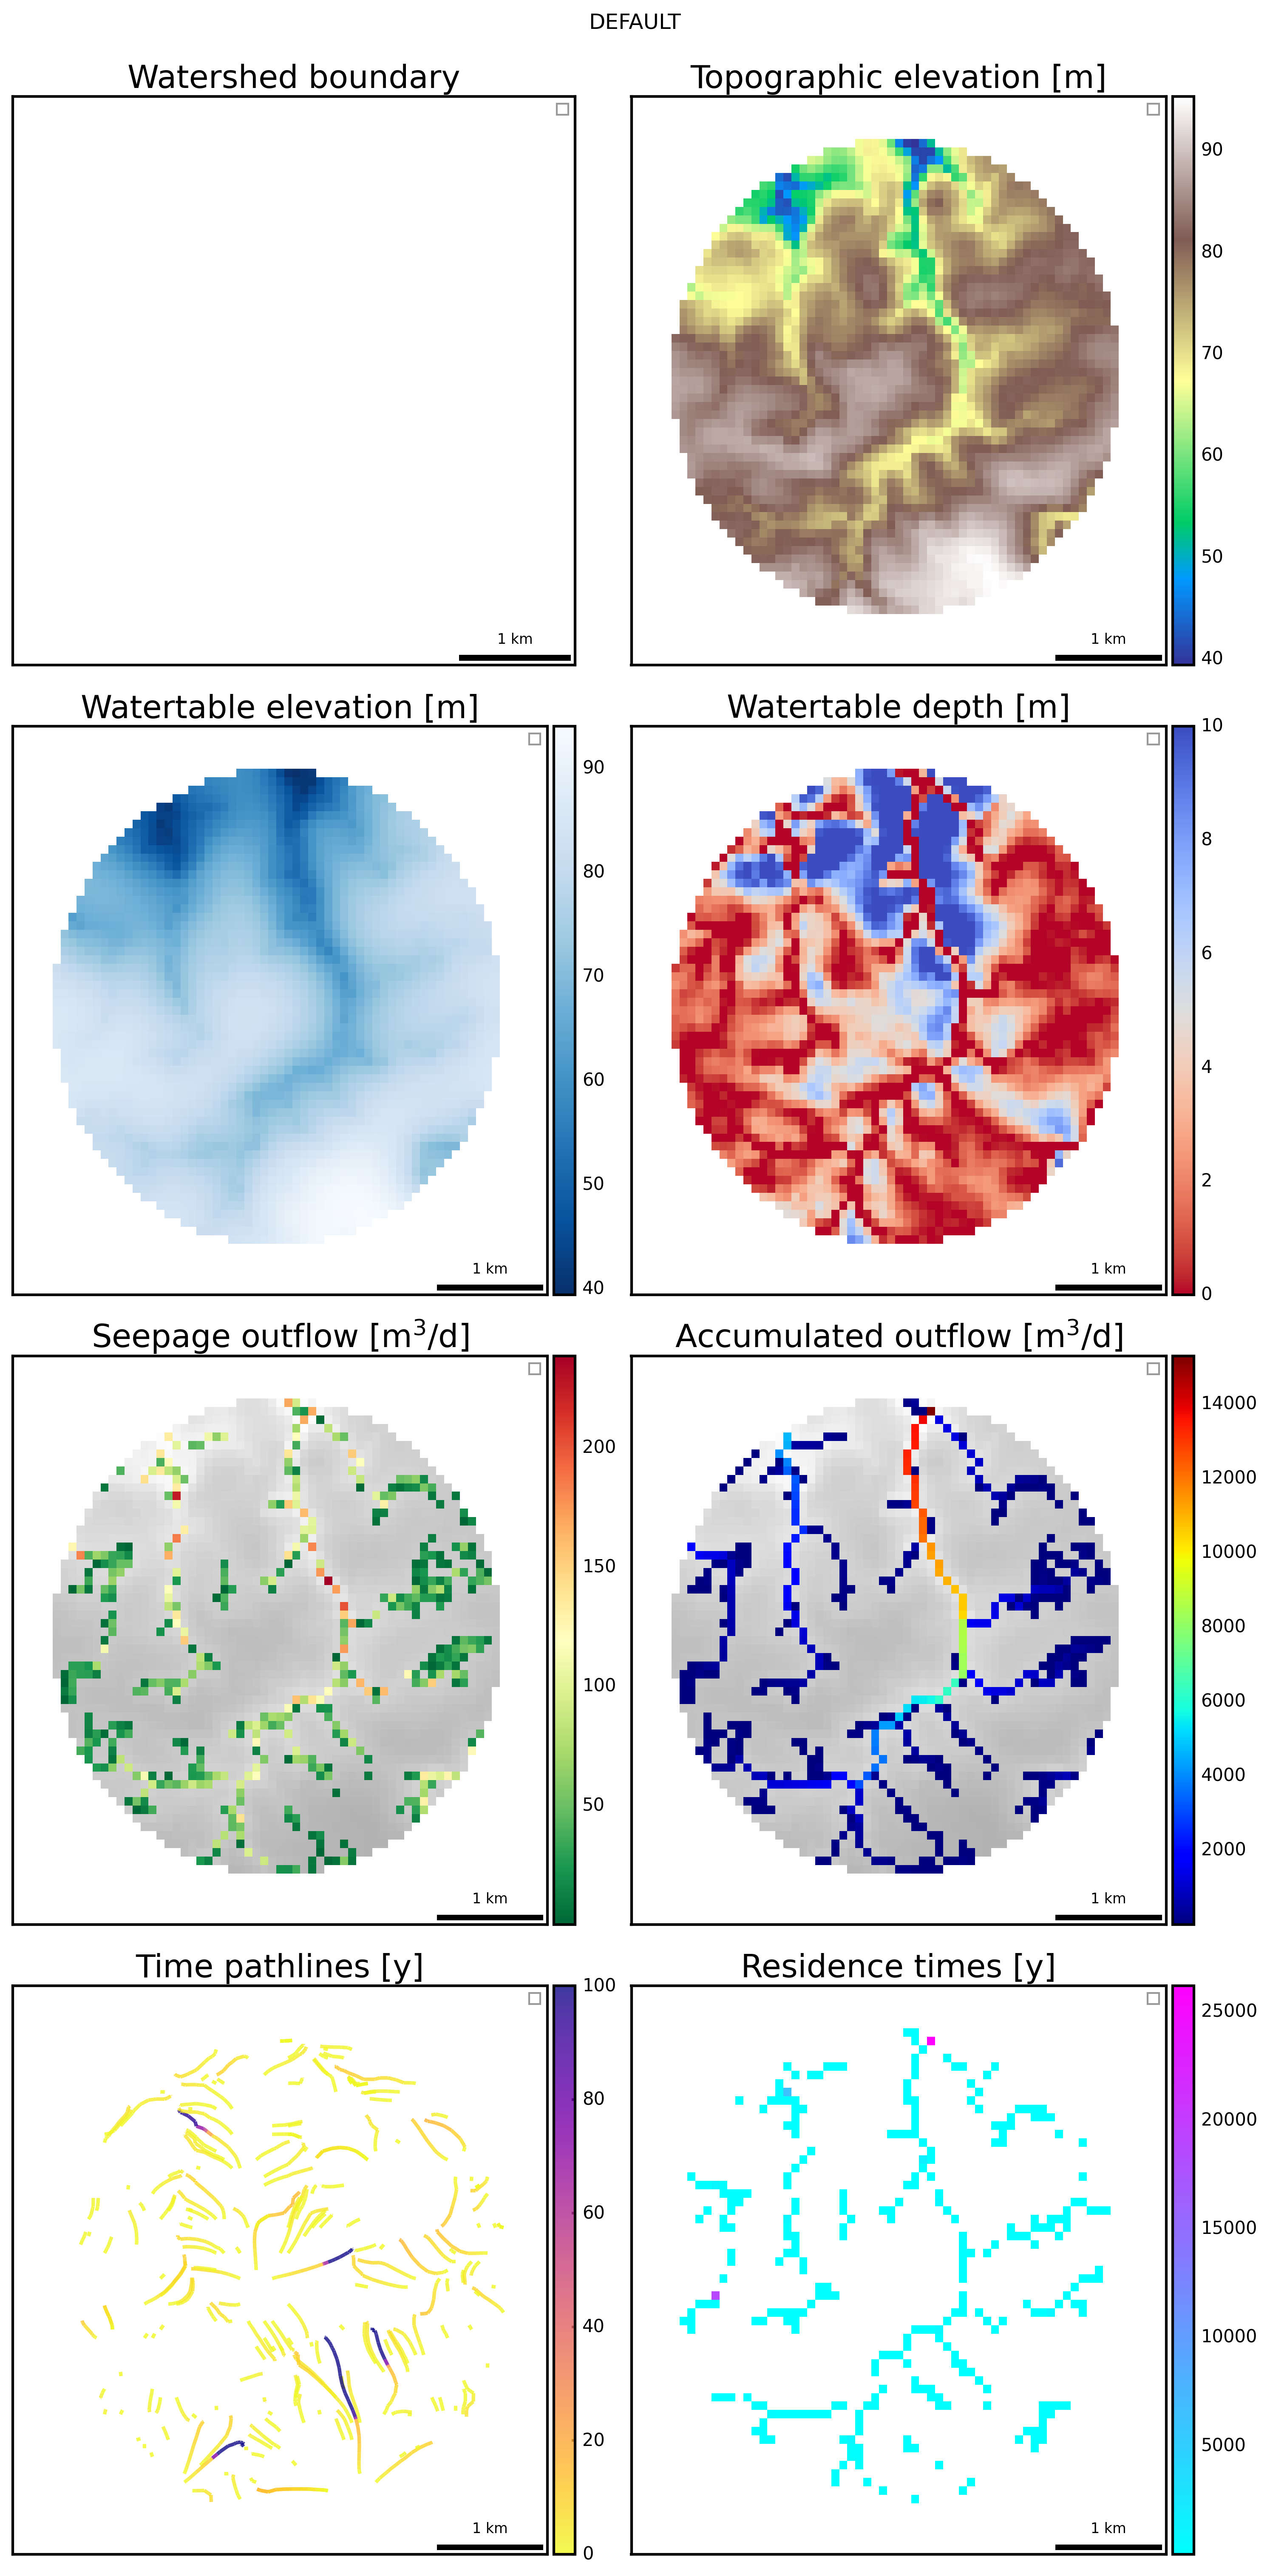

In [ ]:

# if sim_state == 'steady':
visu = visualization_results.Visualization(BV, model_name)
visu.visual2D(object_list = ['map','grid',
                             'watertable', 'watertable_depth',
                             'drain_flow','surface_flow',
                             'pathlines', 'residence_times'
                             ],
              color_scale = [(None,None),(None,None),
                             (None,None),(0,10),
                             (None,None),(None,None),
                             (0,100),(None,None),
                             ],
              lines=250)



In [16]:

if from_dem == None:
    export_vtuvtk.VTK(BV, model_name)
    visu = visualization_results.Visualization(BV, model_name)
    visu.visual3D(interactive=True, object_list=['grid','watertable', 'watertable_depth',
                                                  'surface_flow',
                                                  'drain_flow',
                                                  'pathlines'], view='south-west', lines=100, cloc=(0.7,0.1), z_scale=10)



In [17]:

dem_data = imageio.imread(os.path.join(stable_folder,'geographic','watershed_box_buff_dem.tif')) # dem data
if from_dem == None:
    stream_data = imageio.imread(os.path.join(stable_folder,'hydrography','regional stream network.tif')) # river data
else:
    stream_data = None
watertable_data = imageio.imread(os.path.join(simulations_folder,model_name,r'_postprocess/_rasters/','watertable_elevation_t(0).tif')) # watertable data
interactive = True
visu = visualization_results.Visualization(BV, model_name)
visu.interactive_cross_section(dem_data, watertable_data, stream_data, interactive)



[INFO] Plotting 2D cross-section for model default


[INFO] Matplotlib interactive backend enabled: QtAgg


[WARNING] No contour raster available for cross-section overlay


[WARNING] No river raster available for cross-section overlay


In [18]:

os.chdir(root_dir)
